# Vine-copula forests with MCS-based survivor selection

This notebook is the companion to `08_sklearn_estimators.ipynb`. The single-vine estimators in that notebook commit to one (greedily chosen) vine structure via the Dissmann algorithm. In real datasets the greedy choice is often suboptimal, and many alternative structures are statistically indistinguishable from each other — so it makes sense to *search* over structures and *ensemble* the survivors.

`VineForestDensity` and `VineForestRegressor` implement the random-search-plus-model-confidence-set methodology of Vatter & Nagler (2026):

1. Hold out a fraction of the training data for survivor selection.
2. Sample $M$ candidate vine structures. Uniform sampling over all R-vines uses Joe's generation algorithm (Joe, Cooke & Kurowicka 2011; Algorithm 13 of Joe 2014; implemented in `pyvinecopulib.core.RVineStructure.simulate`). The alternative `"local"` mode draws each tree from the Kendall's-$\tau$-weighted distribution $P(T) \propto \prod_{(j, k) \in T} |\hat\tau_{j, k}|$ via Wilson's loop-erased random walk (Wilson 1996), so the Dissmann maximum spanning tree is the mode.
3. Fit each candidate on a bootstrap resample of the training portion; score on the held-out validation set.
4. Feed the $n_\text{val} \times M$ validation-loss matrix to a dual-split DA test — adapted by Vatter & Nagler (2026) from the discrete-argmin-inference framework of Kim & Ramdas (2025) — to compute a model confidence set. `method="da_mcs_marg"` gives marginal per-model coverage (the default); `"da_mcs_unif"` gives uniform / familywise coverage at the cost of a Bonferroni correction. Hansen, Lunde & Nason (2011) provide the foundational MCS definition.
5. Refit survivors on the full training data; average predictions across them.

We use the Concrete Compressive Strength dataset ($n = 1030$, $p = 8$ features predicting compressive strength in MPa). It's one of the regression benchmarks in Vatter & Nagler (2026) and is small enough to run a $M = 50$ random search in a few minutes on a single core.

In [1]:
import pytest

pytest.importorskip("sklearn")
pytest.importorskip("pandas")
pytest.importorskip("joblib")
pytest.importorskip("scipy")

import time  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from sklearn.datasets import fetch_openml  # noqa: E402
from sklearn.metrics import root_mean_squared_error  # noqa: E402
from sklearn.model_selection import train_test_split  # noqa: E402
from sklearn.preprocessing import StandardScaler  # noqa: E402

from pyvinecopulib.sklearn import (  # noqa: E402
  VineDensity,
  VineForestDensity,
  VineForestRegressor,
  VineRegressor,
)

rng = np.random.default_rng(0)

ninja: warning: premature end of file; recovering


ninja: warning: premature end of file; recovering


ninja: warning: premature end of file; recovering


ninja: warning: premature end of file; recovering


ninja: warning: premature end of file; recovering


ninja: warning: premature end of file; recovering


In [2]:
# Concrete Compressive Strength (OpenML id 4353); last column is the target.
frame = fetch_openml(name="Concrete_Data", version=1, as_frame=True).frame
X = frame.iloc[:, :-1].values
y = frame.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (824, 8), test: (206, 8)


## Regression: single vine vs. forest ensemble

We fit:

- `VineRegressor` (single Dissmann-structure baseline; equivalent to running step 1 of the random search).
- `VineForestRegressor` with `best_only=False` — keep the entire MCS and average predictions (the `RS-E` setting in Vatter & Nagler 2026).

To keep the notebook fast we only ask for the median quantile, so each `predict` call evaluates one statistic per surviving tree. The forest uses $M = 50$ random structures plus the Dissmann baseline (`add_dissmann=True`, the default), giving up to 51 candidates.

In [3]:
base_params = {"mean": True, "quantiles": [0.5]}
M = 50

t0 = time.time()
single = VineRegressor(**base_params).fit(X_train, y_train)
print(f"VineRegressor (single Dissmann): fit {time.time() - t0:.1f}s")

t0 = time.time()
forest_e = VineForestRegressor(
  base_params=base_params,
  n_vines=M,
  n_jobs=1,
  val_fraction=0.25,
  best_only=False,
  random_state=0,
).fit(X_train, y_train)
print(
  f"VineForestRegressor (ensemble):  fit {time.time() - t0:.1f}s "
  f"-> {len(forest_e._estimators)} survivor(s) "
  f"(selection rate {forest_e._selection_rate:.0%}, "
  f"Dissmann in MCS: {forest_e._default_selected})"
)

VineRegressor (single Dissmann): fit 0.4s


VineForestRegressor (ensemble):  fit 54.0s -> 43 survivor(s) (selection rate 84%, Dissmann in MCS: True)


Compare RMSE on the conditional mean.

In [4]:
def rmse(est):
  return root_mean_squared_error(y_test, est.predict(X_test)[:, 0])


print(f"{'model':<35} {'RMSE':>6}")
for name, est in [
  ("VineRegressor (Dissmann)", single),
  ("VineForestRegressor (ensemble)", forest_e),
]:
  print(f"{name:<35} {rmse(est):>6.3f}")

model                                 RMSE


VineRegressor (Dissmann)             7.280


VineForestRegressor (ensemble)       6.719


### Where the survivors sit relative to the Dissmann baseline

`_estimators_logliks` records the held-out validation log-likelihood (mean over validation rows) for every surviving structure. The Dissmann baseline is included when `add_dissmann=True` (it's the last entry of the array). The histogram below shows the distribution of validation log-liks across MCS survivors, with the Dissmann baseline drawn as a vertical line — when the line falls inside the bulk of the histogram the random search hasn't found anything that decisively beats the greedy default, while a line to the left of the bulk indicates that most random structures outperform Dissmann on this dataset.

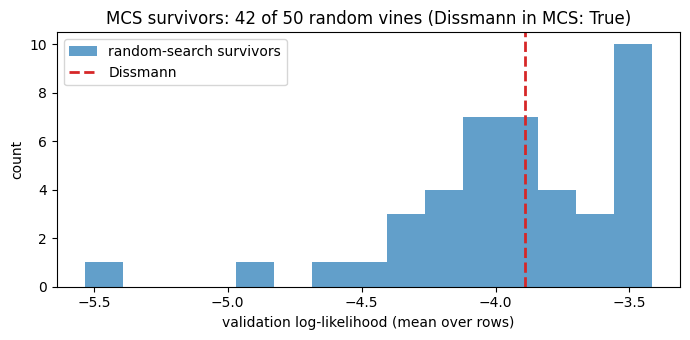

In [5]:
logliks_all = forest_e._estimators_logliks.ravel()
dissmann_loglik = forest_e._default_loglik
# Random-search survivors are everything except the Dissmann entry (which is
# appended last by add_dissmann=True).
random_logliks = logliks_all[:-1] if forest_e._default_selected else logliks_all

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(random_logliks, bins=15, alpha=0.7, label="random-search survivors")
ax.axvline(
  dissmann_loglik, color="C3", linestyle="--", linewidth=2, label="Dissmann"
)
ax.set_xlabel("validation log-likelihood (mean over rows)")
ax.set_ylabel("count")
ax.set_title(
  f"MCS survivors: {len(random_logliks)} of {forest_e.n_vines} "
  f"random vines (Dissmann in MCS: {forest_e._default_selected})"
)
ax.legend()
plt.tight_layout()

### Wilson-weighted local sampling

`vines_sampling="local"` swaps Joe's uniform R-vine sampler for Wilson's loop-erased random walk weighted by Kendall's $\tau$. Each tree $T$ is drawn from $P(T) \propto \prod_{(j, k) \in T} |\hat\tau_{j, k}|$, so the Dissmann maximum spanning tree (the global $\arg\max$) is the mode of the distribution. In practice this concentrates the candidate pool near the greedy structure — useful when Dissmann is already competitive.

In [6]:
t0 = time.time()
forest_local = VineForestRegressor(
  base_params=base_params,
  n_vines=M,
  n_jobs=1,
  val_fraction=0.25,
  vines_sampling="local",
  random_state=0,
).fit(X_train, y_train)
print(
  f"local sampling: fit {time.time() - t0:.1f}s -> "
  f"{len(forest_local._estimators)} survivor(s), "
  f"RMSE={rmse(forest_local):.3f}"
)

local sampling: fit 57.3s -> 34 survivor(s), RMSE=6.523


## Density forest

`VineForestDensity` mirrors the regressor — random search plus MCS-based survivor selection — but on the joint density $\hat f(\mathbf{x}) = M^{-1} \sum_{m=1}^M \hat f_m(\mathbf{x})$ averaged over survivors. `sample(n)` then draws from the mixture-of-densities distribution using a single multinomial allocation followed by one call per surviving base estimator (so the cost stays linear in $n$ rather than scaling with the number of survivors).

In [7]:
t0 = time.time()
dens_forest = VineForestDensity(
  n_vines=M,
  n_jobs=1,
  val_fraction=0.25,
  random_state=0,
).fit(X_train)
print(
  f"VineForestDensity fit: {time.time() - t0:.1f}s -> "
  f"{len(dens_forest._estimators)} survivor(s)"
)

t0 = time.time()
single_dens = VineDensity().fit(X_train)
nll_single = -single_dens.score_samples(X_test).mean()
nll_forest = -dens_forest.score_samples(X_test).mean()
print(f"NLL (single VineDensity):        {nll_single:.3f}")
print(
  f"NLL (VineForestDensity, M={len(dens_forest._estimators)}):  {nll_forest:.3f}"
)

VineForestDensity fit: 15.0s -> 10 survivor(s)


NLL (single VineDensity):        3.790
NLL (VineForestDensity, M=10):  3.207


Quick sanity check on the sampler: draw 1000 synthetic rows from the forest and compare the marginal of the first feature to the training distribution.

sample shape: (1000, 8)


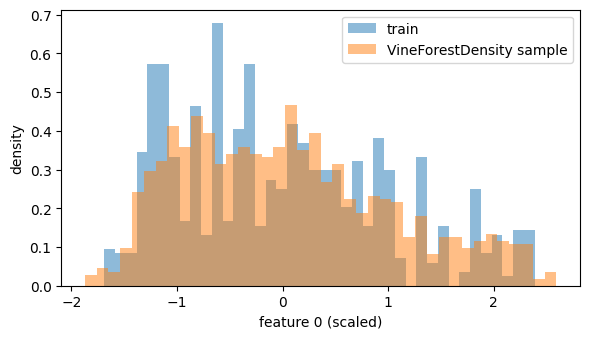

In [8]:
synth = dens_forest.sample(n_samples=1000)
print(f"sample shape: {synth.shape}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(X_train[:, 0], bins=40, alpha=0.5, density=True, label="train")
ax.hist(
  synth[:, 0],
  bins=40,
  alpha=0.5,
  density=True,
  label="VineForestDensity sample",
)
ax.set_xlabel("feature 0 (scaled)")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()

## What's next

- To get the conditional density $f(y \mid x)$ from a forest regressor, reach for the private `VineForestRegressor._loglik_estimator(est, X, y)` directly — it implements the three-term identity $\log f(y \mid x) = \log c_{Y, X}(u_y, u_x) - \log c_X(u_x) + \log f_Y(y)$ from Nagler & Vatter (2024). A future PR may surface this as a public method.
- The MCS itself lives at `pyvinecopulib.sklearn._mcs`. It is private for now; promote to a public utility if you need to apply it to model-selection problems outside vine copulas.